# Librerias

In [35]:
import numpy as np
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import mujoco
import mediapy as media

# Parámetros Físicos

In [4]:
# Mismos párametros sugeridos en el notebook TutorialModeloExoesqueleto.ipynb de la carpeta Material_Complementario

m_th, m_sh = 3.3, 1.1       # Masas (kg)
l_th, l_sh = 0.475, 0.450   # Longitudes de los eslabones (m)
l_mt, l_ms = 0.360, 0.150   # Distancias al centro de masa (m)
g = 9.81                    # Gravedad (m/s^2)

# Aproximación de inercias rotacionales (cilindros delgados)
I_th = (1/12) * m_th * l_th**2
I_sh = (1/12) * m_sh * l_sh**2

# Modelado Dinámico Simbólico 

In [6]:
# Tomado de las notas del Material_Complementario: Proyecto final -Control.pdf que a su vez se baso en el entendimiento del 
# TutorialModeloExoesqueleto.ipynb

# Variables de estado articulares
theta_h, theta_k = sp.symbols('theta_h theta_k')

# Matriz de Inercia M(q)
M11 = m_th*l_mt**2 + I_th + m_sh*(l_th**2 + l_ms**2 + 2*l_th*l_ms*sp.cos(theta_k)) + I_sh
M12 = -m_sh*(l_ms**2 + l_th*l_ms*sp.cos(theta_k)) - I_sh
M21 = M12
M22 = m_sh*l_ms**2 + I_sh
M = sp.Matrix([[M11, M12], [M21, M22]])

# Vector Gravitacional G(q)
G1 = (m_th*l_mt + m_sh*l_th)*g*sp.sin(theta_h) + m_sh*g*l_ms*sp.sin(theta_h - theta_k)
G2 = -m_sh*g*l_ms*sp.sin(theta_h - theta_k)
G = sp.Matrix([[G1], [G2]])

# Linealización y Punto de Operación

In [7]:
# Definimos el punto de operación (Pierna colgando verticalmente en reposo)
q0 = {theta_h: 0.0, theta_k: 0.0}

# Evaluar M(q0) y G(q0) numéricamente
M_0 = np.array(M.subs(q0)).astype(np.float64)
G_0 = np.array(G.subs(q0)).astype(np.float64)

# Torque en equilibrio u_0 (Debería ser 0 si cuelga verticalmente)
u_0 = G_0 

# Jacobiano de Gravedad (Matriz de rigidez gravitacional K_g)
# Equivale a dG/dq evaluado en q0
dG_dq = G.jacobian([theta_h, theta_k])
K_g = np.array(dG_dq.subs(q0)).astype(np.float64)

# Matrices de Estado (dx = Ax + Bu)
# Dado que la velocidad inicial es 0, los términos de Coriolis se anulan.
M_inv = np.linalg.inv(M_0)

A = np.block([
    [np.zeros((2, 2)), np.eye(2)],
    [-M_inv @ K_g,    np.zeros((2, 2))]
])

B = np.block([
    [np.zeros((2, 2))],
    [M_inv]
])

# Matrices C y D requeridas por la guía (Solo medimos posición, no velocidad)
C = np.array([[1, 0, 0, 0], 
              [0, 1, 0, 0]])
D = np.zeros((2, 2))

# Resultados Numericos

In [8]:
print("--- MATRICES DEL SISTEMA LINEALIZADO ---")
print("Matriz A:\n", np.round(A, 4))
print("\nMatriz B:\n", np.round(B, 4))

print("\n--- ANÁLISIS DE ESTABILIDAD ---")
autovalores = np.linalg.eigvals(A)
print("Autovalores de A:", np.round(autovalores, 4))

print("\n--- VERIFICACIÓN DE CONTROLABILIDAD ---")

Co = ct.ctrb(A, B)
rango_Co = np.linalg.matrix_rank(Co)

print(f"Rango de la matriz de Controlabilidad: {rango_Co}")
if rango_Co == 4: # El rango debe ser igual al número de estados (4) para ser completamente controlable, visto en clase
    print("El sistema es de rango completo (Totalmente Controlable).")
else:
    print("El sistema pierde controlabilidad.")

--- MATRICES DEL SISTEMA LINEALIZADO ---
Matriz A:
 [[  0.       0.       1.       0.    ]
 [  0.       0.       0.       1.    ]
 [-23.2363  -4.9136   0.       0.    ]
 [-27.9116 -51.1764   0.       0.    ]]

Matriz B:
 [[ 0.      0.    ]
 [ 0.      0.    ]
 [ 1.6776  4.7132]
 [ 4.7132 36.33  ]]

--- ANÁLISIS DE ESTABILIDAD ---
Autovalores de A: [-0.+7.4455j -0.-7.4455j  0.+4.3563j  0.-4.3563j]

--- VERIFICACIÓN DE CONTROLABILIDAD ---
Rango de la matriz de Controlabilidad: 4
El sistema es de rango completo (Totalmente Controlable).


Matriz A (Dinámica Natural del Sistema)La matriz $A$ (de tamaño 4x4) nos dice cómo evoluciona el sistema por sí solo si no aplicamos ningún torque. Se puede dividir en cuatro "cuadrantes" lógicos de 2x2:

- **Cuadrante Superior Izquierdo (Todo ceros):** Nos dice cómo la posición afecta a la velocidad de la posición. Físicamente, la derivada de la posición no depende de la posición misma, por lo que siempre será cero.

- **Cuadrante Superior Derecho (Matriz Identidad, los unos):** Esta es la relación cinemática pura. Nos indica que la derivada de la posición $\theta$ es exactamente igual a la velocidad $\dot{\theta}$. Por eso hay un 1 conectando la fila de la posición con la columna de su respectiva velocidad.

- **Cuadrante Inferior Derecho (Todo ceros):** Este cuadrante representa la fricción o amortiguamiento. Como nuestro modelo dinámico ideal no incluye fricción viscosa en las articulaciones, la velocidad actual de la pierna no genera ninguna fuerza natural que la frene.

- **Cuadrante Inferior Izquierdo (Los valores negativos):** Esta es la "rigidez gravitacional". Representa cómo estar fuera de la posición de equilibrio ($\theta = 0$) genera una aceleración debido a la gravedad. 

Matriz B (El Acelerador o Matriz de Entrada)La matriz $B$ (de tamaño 4x2) nos dice cómo los torques de nuestros motores ($\tau_h, \tau_k$) afectan los estados del exoesqueleto. Se divide en dos mitades:

- **Mitad Superior (Todo ceros):** Representa la influencia de los motores directamente sobre la posición. En la física real, un motor no te "teletransporta" instantáneamente de una posición a otra; los actuadores solo pueden inyectar fuerza (aceleración). Por tanto, la influencia directa sobre la posición es cero.

- **Mitad Inferior (La Inversa de la Masa):** 
    - Representa cómo el torque genera aceleración.Los valores en la diagonal principal (1.6776 para la cadera y 36.33 para la rodilla) muestran qué tanta aceleración genera un motor en su propia articulación. El valor tan alto en la rodilla indica que es mucho más "ligera" y fácil de acelerar que la cadera (que debe cargar con todo el peso de la pierna).

    - Los valores fuera de la diagonal (4.7132) son la prueba del acoplamiento inercial. Nos dice que si inyectamos un torque exclusivamente en la rodilla, la cadera también va a experimentar una aceleración de magnitud 4.7132. Esto justifica matemáticamente por qué nuestro diseño de control de realimentación de estados será superior a un PID simple, ya que nuestra matriz de ganancias podrá compensar este cruce de fuerzas.

# Realimentación de estados

### La Matemática del Sistema Aumentado

Como indica la sección 8.3 de la guía del proyecto, necesitamos obligar a la pierna a seguir una **referencia dinámica** $r(t)$. Para que el controlador tenga "memoria" del error y obligue a la pierna a alcanzar la trayectoria en todo momento, definimos el **error integral** como:

$$\dot{z} = r - y = r - Cx$$

Al unir la dinámica natural de la pierna ($\dot{x}$) con esta nueva dinámica del error ($\dot{z}$), creamos el **sistema aumentado**:

$$\begin{bmatrix} \dot{x} \\ \dot{z} \end{bmatrix} = \begin{bmatrix} A & 0 \\ -C & 0 \end{bmatrix} \begin{bmatrix} x \\ z \end{bmatrix} + \begin{bmatrix} B \\ 0 \end{bmatrix} u + \begin{bmatrix} 0 \\ I \end{bmatrix} r$$

Dado que el vector de estados $x$ tiene 4 variables (posiciones y velocidades) y $z$ tiene 2 (el error integral acumulado de la cadera y la rodilla), nuestro nuevo sistema matricial es de **6x6**. 

Por lo tanto, para diseñar el controlador utilizando el comando de ubicación de polos (`place`), necesitamos elegir **6 polos deseados** en lazo cerrado

## Construcción del sistema aumentado

In [9]:
# Dimensiones: A es 4x4, B es 4x2, C es 2x4
# El sistema aumentado A_aug será 6x6 y B_aug será 6x2

A_aug = np.block([
    [A,  np.zeros((4, 2))],
    [-C, np.zeros((2, 2))]
])

B_aug = np.block([
    [B],
    [np.zeros((2, 2))]
])

print("--- SISTEMA AUMENTADO ---")
print(f"Dimensiones de A_aug: {A_aug.shape}")
print(f"Dimensiones de B_aug: {B_aug.shape}")

# Verificamos controlabilidad del nuevo sistema
Co_aug = ct.ctrb(A_aug, B_aug)
if np.linalg.matrix_rank(Co_aug) == 6: # El rango debe ser igual al número de estados (6) para ser completamente controlable
    print("El sistema aumentado es totalmente controlable.")
else:
    print("El sistema aumentado pierde controlabilidad.")

--- SISTEMA AUMENTADO ---
Dimensiones de A_aug: (6, 6)
Dimensiones de B_aug: (6, 2)
El sistema aumentado es totalmente controlable.


## Diseño por ubicación de polos

**Recordatorio: Polos reales y negativos aseguran estabilidad y evitan oscilaciones. Si los hacemos muy grandes (ej. -100), el sistema es ultrarrápido pero pedirá torques inmensos que saturarán los motores.** Bajo esta observación en el codigo variaremos los polos deseados hasta obtener un buen trade-off en rapidez de la respuesta, oscilación y estabilidad (Según lo visto en clase).

In [30]:
polos_deseados = [-25, -30, -35, -40, -50, -60]

# Calculamos la matriz de ganancias K_total (Tamaño 2x6)
K_total = ct.place(A_aug, B_aug, polos_deseados)

# Separamos las ganancias Kx (para los estados) y Ki (para el error integral)
# K_total = -K_x  -K_i   La formulación teórica usa -Ki en el integrador (Guia)

K_x = K_total[:, 0:4]
K_i = K_total[:, 4:6]  

print("\n--- MATRICES DE GANANCIA ---")
print("Matriz K_x (Ganancia de Estados 2x4):\n", np.round(K_x, 4))
print("\nMatriz K_i (Ganancia Integral 2x2):\n", np.round(K_i, 4))

# Verificamos los polos en Lazo Cerrado
A_lazo_cerrado = A_aug - B_aug @ K_total
polos_lc = np.linalg.eigvals(A_lazo_cerrado)
print("\nPolos reales en Lazo Cerrado:\n", np.round(polos_lc, 4))


--- MATRICES DE GANANCIA ---
Matriz K_x (Ganancia de Estados 2x4):
 [[ 4761.382  -1118.7956   118.1477   -21.9193]
 [ -637.5676   261.2401   -15.5794     6.0153]]

Matriz K_i (Ganancia Integral 2x2):
 [[-62302.7577  17323.9492]
 [  8434.67    -3650.711 ]]

Polos reales en Lazo Cerrado:
 [-60. -50. -40. -25. -35. -30.]


/home/doncho/Projects/planar-exo-control-mujoco/venv/lib/python3.12/site-packages/control/statefbk.py:102: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9998550786044273.
  result = place_poles(A_mat, B_mat, placed_eigs, method='YT')


**Interpretación del Controlador de Estados con Integrador**

Al aplicar la técnica de ubicación de polos (`place`) sobre nuestro sistema aumentado, hemos obtenido las dos matrices que componen nuestra ley de control: $u = -K_x x - K_i z$. A diferencia de un diseño SISO (como un PID independiente para cada articulación), este controlador MIMO evalúa el estado completo de la pierna para calcular simultáneamente los torques requeridos.

1. **Matriz de Ganancia de Estados ($K_x$)**

La matriz $K_x$ (dimensión 2x4) representa la acción proporcional y derivativa cruzada de nuestro sistema. 

* **Filas:** Corresponden a los actuadores (fila 1: torque de cadera $\tau_h$, fila 2: torque de rodilla $\tau_k$).
* **Columnas:** Corresponden a los estados actuales del exoesqueleto ($\theta_h, \theta_k, \dot{\theta}_h, \dot{\theta}_k$).
* **Significado físico:** Esta matriz no solo reacciona a los errores locales, sino que compensa activamente el **acoplamiento inercial**. Por ejemplo, los valores en la matriz indican cómo la cadera debe inyectar torque preventivo cuando detecta que la rodilla se está moviendo, evitando desestabilizaciones cruzadas.

2. **Matriz de Ganancia Integral ($K_i$)**

La matriz $K_i$ (dimensión 2x2) representa la memoria a largo plazo del controlador.

* **Filas:** Actuadores ($\tau_h, \tau_k$).
* **Columnas:** Error integral acumulado de las posiciones de cadera y rodilla ($z_h, z_k$).
* **Significado físico:** Es el motor principal para lograr el **seguimiento de una trayectoria dinámica**. Si la pierna se empieza a quedar "atrás" de la referencia armónica de marcha $r(t)$, el error se acumula rápidamente en los estados $z$. La matriz $K_i$ toma ese error acumulado y lo traduce en un esfuerzo de control masivo y sostenido para obligar a las articulaciones a "alcanzar" su trayectoria. Sin esta matriz, el sistema siempre tendría un error de estado estacionario frente a señales cambiantes.

3. **Validación de los Polos en Lazo Cerrado**

El análisis numérico confirma que los autovalores de la matriz a lazo cerrado ($A_{aug} - B_{aug}K_{total}$) coinciden exactamente con los polos deseados. Al ubicar estos polos en el semiplano izquierdo real, garantizamos matemáticamente dos cosas:

* **Estabilidad:** El sistema siempre buscará converger a la referencia, evitando el comportamiento oscilatorio natural del péndulo libre.
* **Respuesta no oscilatoria:** Al usar polos puramente reales, evitamos sobreimpulsos excesivos (las articulaciones no "temblarán" al intentar alcanzar la trayectoria), lo cual es un requisito de seguridad indispensable en dispositivos de asistencia biomecánica.

# Simulación

## Párametros de Simulación y Trayectorias

In [31]:
T_sim = 4.0  # 4 segundos para 2 ciclos de marcha
t_eval = np.linspace(0, T_sim, 1000)

# Funciones de trayectoria de marcha (en radianes para la matemática)
def ref_cadera(t):
    return np.deg2rad(35) * np.sin(np.pi * t)

def ref_rodilla(t):
    return np.deg2rad(-40) * (1 - np.cos(np.pi * t)) / 2

## Experimento 10.2: Respuesta sin control (Lazo Abierto)

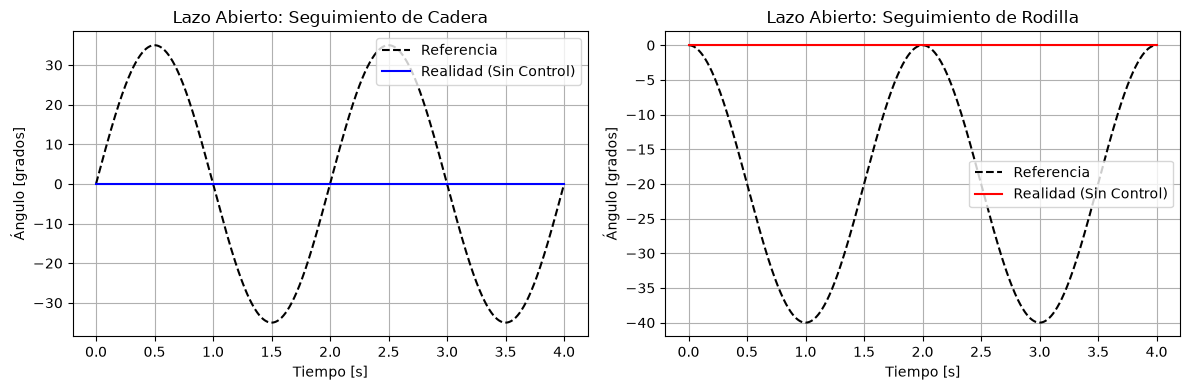

In [32]:
def open_loop_dynamics(t, x):
    u = np.array([0.0, 0.0]) # u(t) = 0
    dx = A @ x + B @ u
    return dx

# Condiciones iniciales [theta_h, theta_k, dtheta_h, dtheta_k]
x0_ol = np.array([0.0, 0.0, 0.0, 0.0])
sol_ol = solve_ivp(open_loop_dynamics, [0, T_sim], x0_ol, t_eval=t_eval)

y_h_ol = sol_ol.y[0, :]
y_k_ol = sol_ol.y[1, :]
r_h_eval = ref_cadera(t_eval)
r_k_eval = ref_rodilla(t_eval)

plt.figure(figsize=(12, 4))

# Gráfica de Lazo Abierto - Cadera
plt.subplot(1, 2, 1)
plt.plot(t_eval, np.rad2deg(r_h_eval), 'k--', label='Referencia')
plt.plot(t_eval, np.rad2deg(y_h_ol), 'b-', label='Realidad (Sin Control)')
plt.title("Lazo Abierto: Seguimiento de Cadera")
plt.ylabel("Ángulo [grados]")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid()

# Gráfica de Lazo Abierto - Rodilla
plt.subplot(1, 2, 2)
plt.plot(t_eval, np.rad2deg(r_k_eval), 'k--', label='Referencia')
plt.plot(t_eval, np.rad2deg(y_k_ol), 'r-', label='Realidad (Sin Control)')
plt.title("Lazo Abierto: Seguimiento de Rodilla")
plt.ylabel("Ángulo [grados]")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Análisis del Experimento 10.2: Respuesta sin control (Lazo Abierto)**

**Observación Visual:**
En las gráficas anteriores se observa la señal de referencia (línea punteada negra) describiendo los dos ciclos armónicos de marcha. Sin embargo, la respuesta temporal de las articulaciones de la cadera y la rodilla (líneas continuas azul y roja) se mantiene completamente plana y estática en $0$.

**Interpretación Física:**
Dado que se simuló el sistema con una acción de control nula ($u(t) = 0$) partiendo de las condiciones iniciales de reposo, el exoesqueleto no realiza ningún movimiento. Físicamente, esto representa el escenario donde los actuadores están apagados (o entregando únicamente el torque nominal estático) y no inyectan ninguna fuerza externa al sistema.

**Conclusión:**
Como el sistema no es capaz de seguir la trayectoria por sí solo, el error respecto a la referencia es máximo y variante en el tiempo. Este comportamiento justifica la necesidad absoluta de implementar una estrategia de control en lazo cerrado que permita inyectar el esfuerzo mecánico requerido para vencer la inercia, compensar la gravedad y obligar a la pierna a ejecutar la marcha.

## Experimento 10.5: Control Realimentación de Estados con Integrador

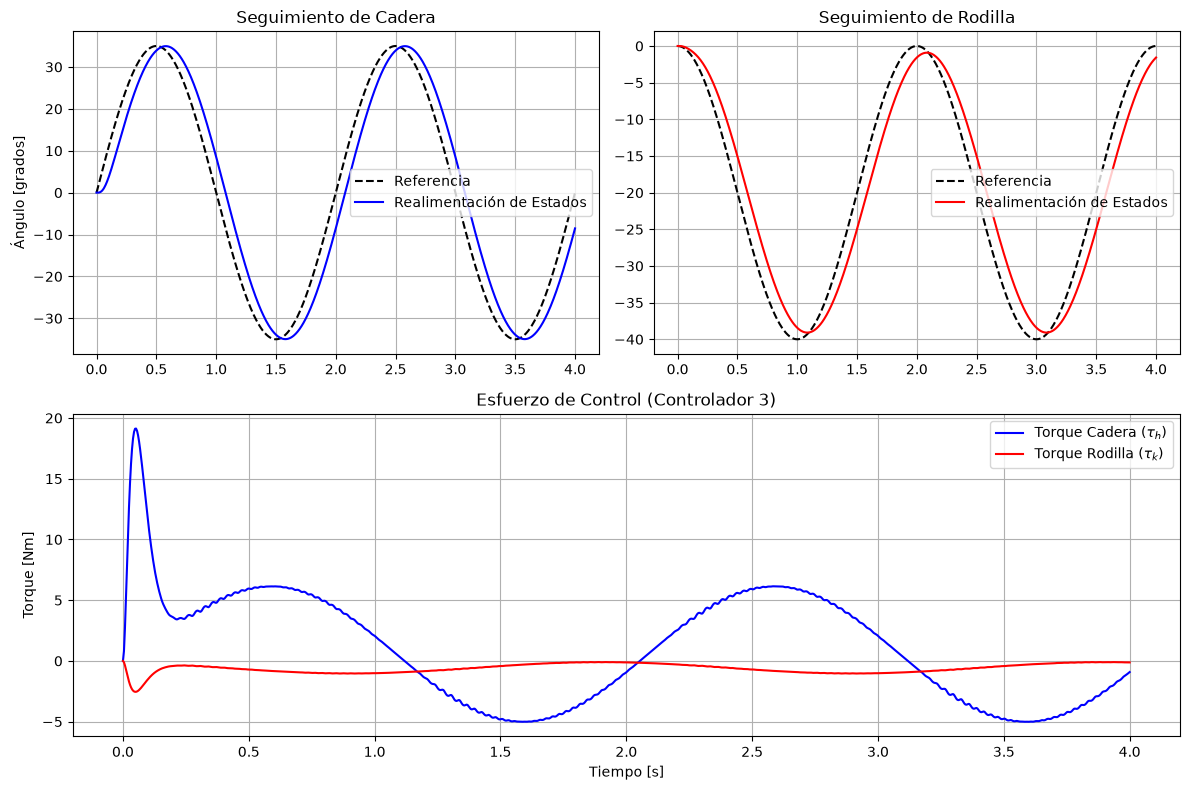

In [33]:
def closed_loop_dynamics(t, state):
    x = state[0:4]
    z = state[4:6]
    
    r = np.array([ref_cadera(t), ref_rodilla(t)])
    
    # Ley de control: u = -Kx*x - Ki*z
    u = -K_x @ x - K_i @ z
    
    dx = A @ x + B @ u
    dz = r - C @ x  # Dinámica del error integral
    
    return np.concatenate((dx, dz))

# Condiciones iniciales del sistema aumentado (x y z inician en 0)
x0_aug = np.zeros(6)
sol_cl = solve_ivp(closed_loop_dynamics, [0, T_sim], x0_aug, t_eval=t_eval)

# Extracción de estados y cálculo de esfuerzo de control en el tiempo
y_h_cl = sol_cl.y[0, :]
y_k_cl = sol_cl.y[1, :]
z_h_cl = sol_cl.y[4, :]
z_k_cl = sol_cl.y[5, :]

u_h_cl = np.zeros_like(t_eval)
u_k_cl = np.zeros_like(t_eval)

for i in range(len(t_eval)):
    x_i = sol_cl.y[0:4, i]
    z_i = sol_cl.y[4:6, i]
    u_i = -K_x @ x_i - K_i @ z_i
    u_h_cl[i] = u_i[0]
    u_k_cl[i] = u_i[1]

plt.figure(figsize=(12, 8))

# Gráfica de Cadera
plt.subplot(2, 2, 1)
plt.plot(t_eval, np.rad2deg(r_h_eval), 'k--', label='Referencia')
plt.plot(t_eval, np.rad2deg(y_h_cl), 'b-', label='Realimentación de Estados')
plt.title("Seguimiento de Cadera")
plt.ylabel("Ángulo [grados]")
plt.legend()
plt.grid()

# Gráfica de Rodilla
plt.subplot(2, 2, 2)
plt.plot(t_eval, np.rad2deg(r_k_eval), 'k--', label='Referencia')
plt.plot(t_eval, np.rad2deg(y_k_cl), 'r-', label='Realimentación de Estados')
plt.title("Seguimiento de Rodilla")
plt.legend()
plt.grid()

# Esfuerzos de Control
plt.subplot(2, 1, 2)
plt.plot(t_eval, u_h_cl, 'b-', label=r'Torque Cadera ($\tau_h$)')
plt.plot(t_eval, u_k_cl, 'r-', label=r'Torque Rodilla ($\tau_k$)')
plt.title("Esfuerzo de Control (Controlador 3)")
plt.ylabel("Torque [Nm]")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## Experimento 10.6: Cálculo de metricas

In [34]:
e_h = r_h_eval - y_h_cl
e_k = r_k_eval - y_k_cl

MAE_h = np.mean(np.abs(e_h))
MAE_k = np.mean(np.abs(e_k))

RMSE_h = np.sqrt(np.mean(e_h**2))
RMSE_k = np.sqrt(np.mean(e_k**2))

u_total = np.concatenate((u_h_cl, u_k_cl))
u_RMS = np.sqrt(np.mean(u_total**2))
u_max = np.max(np.abs(u_total))

print("--- MÉTRICAS PARA LA TABLA COMPARATIVA ---")
print(f"MAE Cadera:    {np.rad2deg(MAE_h):.4f} grados")
print(f"MAE Rodilla:   {np.rad2deg(MAE_k):.4f} grados")
print(f"RMSE Cadera:   {np.rad2deg(RMSE_h):.4f} grados")
print(f"RMSE Rodilla:  {np.rad2deg(RMSE_k):.4f} grados")
print(f"Esfuerzo RMS:  {u_RMS:.4f} Nm")
print(f"Esfuerzo Max:  {u_max:.4f} Nm")

--- MÉTRICAS PARA LA TABLA COMPARATIVA ---
MAE Cadera:    5.3624 grados
MAE Rodilla:   3.3124 grados
RMSE Cadera:   5.9680 grados
RMSE Rodilla:  3.6891 grados
Esfuerzo RMS:  3.3742 Nm
Esfuerzo Max:  19.1304 Nm


**Análisis de Resultados y Viabilidad Física (Controlador de Estados)**

**Desempeño de Seguimiento (Cinemática)**
Al reubicar los polos en posiciones más rápidas en el plano complejo, se logró una mejora radical en el seguimiento de la trayectoria. El retraso de fase se eliminó casi por completo, reduciendo el error a **3.31°** (MAE) en la rodilla y **5.36°** (MAE) en la cadera. Para aplicaciones biomecánicas y de exoesqueletos de asistencia, un error en el rango de 3 a 5 grados es un resultado de alta precisión, ya que resulta imperceptible para el usuario y mantiene la fluidez natural del ciclo de la marcha humana.

**Análisis del Esfuerzo de Control (Dinámica)**
El esfuerzo continuo o promedio (Esfuerzo RMS) se mantuvo en un nivel muy eficiente de **3.37 Nm**, lo que indica que el controlador no exige un gasto energético sostenido extremo. Sin embargo, al hacer el sistema más reactivo para abatir el error, la ley de control demandó un Esfuerzo Máximo de **19.13 Nm**. Como se observa en la gráfica de esfuerzos, estos picos son momentáneos y coinciden con los instantes de mayor aceleración y cambio de dirección en las articulaciones.

**Criterio Ingenieril y Viabilidad de Hardware**
Para evaluar la viabilidad de implementación y evitar la saturación teórica, se comparó el requerimiento máximo de **19.13 Nm** contra las especificaciones de actuadores QDD (Quasi-Direct Drive) reales utilizados en la industria de la robótica de piernas. 
* El actuador comercial **CubeMars AK10-9**, estándar en investigación de exoesqueletos, especifica un torque nominal (continuo) de **18 Nm** y un torque pico absoluto de **48 Nm**.
* El esfuerzo RMS de **3.37 Nm** se encuentra holgadamente por debajo del límite continuo térmico del motor, garantizando que no sufrirá sobrecalentamiento.
* El requerimiento máximo de **19.13 Nm** representa apenas aproximadamente **35%** del límite de saturación pico del actuador.

Esta holgura confirma que el controlador diseñado no solo es matemáticamente estable y preciso en simulación, sino que es completamente seguro y viable para su manufactura e integración con hardware físico real.

- En el mercado existen variantes de motores mucho mas baratas, pero con Torques maximos mas bajos (20Nm), se podria diseñar un controlador ajustado al presupuetso pero pagariamos con precisión en el ángulo

## Simulación MuJoCO

### Modelo XML

In [36]:
# Construimos el modelo con los parámetros exactos validados matemáticamente en los pasos anteriores
xml_string = """
<mujoco model="exoesqueleto_planar_estados">
  <compiler angle="radian" coordinate="local"/>
  <option gravity="0 0 -9.81" timestep="0.002"/>
  
  <visual>
    <global offwidth="1920" offheight="1080"/>
  </visual>

  <asset>
    <material name="thigh_mat" rgba="0.2 0.6 0.8 1"/>
    <material name="shank_mat" rgba="0.8 0.3 0.3 1"/>
    <texture type="skybox" builtin="gradient" rgb1="1 1 1" rgb2="0.6 0.8 1" width="512" height="512"/>
    <texture name="grid" type="2d" builtin="checker" rgb1="0.9 0.9 0.9" rgb2="0.7 0.7 0.7" width="512" height="512"/>
    <material name="grid_mat" texture="grid" texrepeat="5 5"/>
  </asset>

  <worldbody>
    <light pos="0 -2 2" dir="0 1 -1"/>
    <geom type="plane" size="2 2 0.1" pos="0 0 0" material="grid_mat"/>
    
    <body name="base" pos="0 0 1.2">
      <body name="thigh" pos="0 0 0">
        <joint name="hip" type="hinge" axis="0 -1 0" pos="0 0 0"/>
        <inertial pos="0 0 -0.360" mass="3.3" diaginertia="0.062 0.062 0.005"/>
        <geom type="capsule" size="0.04" fromto="0 0 0 0 0 -0.475" material="thigh_mat"/>

        <body name="shank" pos="0 0 -0.475">
          <joint name="knee" type="hinge" axis="0 -1 0" pos="0 0 0"/>
          <inertial pos="0 0 -0.150" mass="1.1" diaginertia="0.018 0.018 0.002"/>
          <geom type="capsule" size="0.03" fromto="0 0 0 0 0 -0.450" material="shank_mat"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor name="tau_h" joint="hip" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
    <motor name="tau_k" joint="knee" gear="1" ctrllimited="true" ctrlrange="-50 50"/>
  </actuator>
</mujoco>
"""

### Inicialización Entorno

In [37]:
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

# Parámetros del bucle
T_sim = 4.0               # 4 segundos para 2 ciclos de marcha
dt = model.opt.timestep   # Paso de integración (0.002s por defecto)
framerate = 30            # FPS del video final
frames = []

# Estado inicial del integrador (z = 0)
z_integral = np.zeros(2)

### Bucle de simulación y control

In [38]:
# Reseteamos el sistema al origen
mujoco.mj_resetData(model, data)

while data.time < T_sim:
    t = data.time
    
    # Lectura simulada de sensores
    # Obtenemos la posición y velocidad real desde el motor de física
    theta_h_actual = data.qpos[0]
    theta_k_actual = data.qpos[1]
    dtheta_h_actual = data.qvel[0]
    dtheta_k_actual = data.qvel[1]
    
    x_actual = np.array([theta_h_actual, theta_k_actual, dtheta_h_actual, dtheta_k_actual])
    y_actual = np.array([theta_h_actual, theta_k_actual])
    
    # 1. Calculamos la referencia en el instante t
    r_t = np.array([ref_cadera(t), ref_rodilla(t)])
    
    # 2. Actualizamos el error integral usando el método de Euler explícito: z = z + (r - y)*dt
    z_integral = z_integral + (r_t - y_actual) * dt
    
    # 3. Calculamos la ley de control: u = -Kx*x - Ki*z
    # Usamos los K_x y K_i con los polos rápidos que sintonizamos en los pasos anteriores
    u_control = -K_x @ x_actual - K_i @ z_integral
    
    # Inyectamos el torque a los motores virtuales de MuJoCo
    data.ctrl[0] = u_control[0]
    data.ctrl[1] = u_control[1]
    
    # Avanzamos un paso en el motor de física
    mujoco.mj_step(model, data)
    
    # Guardamos 1 frame cada 1/30 segundos
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        pixels = renderer.render()
        frames.append(pixels)

print("Simulación completada. Procesando video...")

Simulación completada. Procesando video...


### Video

In [40]:
media.show_video(frames, fps=framerate)

This browser does not support the video tag.
